# 04 — Similarity and Distance Analysis

This notebook turns genre-level and book-level texts into vectors and measures similarity between them.

It connects the project to the course units on vector-space models and distance measurement.

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/ALPcourse_Biblical_Hebrew_Project/biblical_hebrew_genre_analysis")
NOTEBOOK_DIR = PROJECT_DIR / "notebooks"
DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = PROJECT_DIR / "output"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"
DOCS_DIR = PROJECT_DIR / "docs"
POSTER_DIR = PROJECT_DIR / "poster"

for folder in [PROCESSED_DIR, TABLES_DIR, FIGURES_DIR, DOCS_DIR, POSTER_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

os.chdir(NOTEBOOK_DIR)
print("Project directory:", PROJECT_DIR)
print("Current folder:", os.getcwd())


!pip -q install pandas scikit-learn matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, cosine_distances

Mounted at /content/drive
Project directory: /content/drive/MyDrive/ALPcourse_Biblical_Hebrew_Project/biblical_hebrew_genre_analysis
Current folder: /content/drive/MyDrive/ALPcourse_Biblical_Hebrew_Project/biblical_hebrew_genre_analysis/notebooks


## 2. Load content tokens

In [2]:
content = pd.read_csv(PROCESSED_DIR / "biblical_hebrew_content_tokens.csv")
content["lex_clean"] = content["lex_clean"].astype(str).str.strip()

print("Content tokens:", len(content))
print(content.groupby("genre").size())

content.head()

Content tokens: 14707
genre
Law              2971
Narrative        4057
Poetry_Wisdom    3978
Prophecy         3701
dtype: int64


,book,chapter,verse,genre,word_node,word,lex,pos,word_utf8,gloss,lex_clean
0,Genesis,37,1,Narrative,20166,יֵּ֣שֶׁב,JCB[,verb,יֵּ֣שֶׁב,sit,JCB[
1,Genesis,37,1,Narrative,20169,אֶ֖רֶץ,>RY/,subs,אֶ֖רֶץ,earth,>RY/
2,Genesis,37,1,Narrative,20170,מְגוּרֵ֣י,MGWRJM/,subs,מְגוּרֵ֣י,neighbourhood,MGWRJM/
3,Genesis,37,1,Narrative,20171,אָבִ֑יו,>B/,subs,אָבִ֑יו,father,>B/
4,Genesis,37,1,Narrative,20173,אֶ֖רֶץ,>RY/,subs,אֶ֖רֶץ,earth,>RY/


## 3. Genre-level cosine similarity

In [3]:
genre_documents = (
    content.groupby("genre")["lex_clean"]
    .apply(lambda values: " ".join(values.astype(str)))
    .sort_index()
)

vectorizer = TfidfVectorizer(lowercase=False, tokenizer=str.split, token_pattern=None)
X = vectorizer.fit_transform(genre_documents.values)

genres = list(genre_documents.index)
similarity = cosine_similarity(X)
distance = cosine_distances(X)

similarity_df = pd.DataFrame(similarity, index=genres, columns=genres)
distance_df = pd.DataFrame(distance, index=genres, columns=genres)

similarity_df.to_csv(TABLES_DIR / "genre_cosine_similarity.csv")
distance_df.to_csv(TABLES_DIR / "genre_cosine_distance.csv")

print("Cosine similarity between genres:")
display(similarity_df)

Cosine similarity between genres:


,Law,Narrative,Poetry_Wisdom,Prophecy
Law,1.000000,0.416679,0.401122,0.455519
Narrative,0.416679,1.000000,0.444826,0.685129
Poetry_Wisdom,0.401122,0.444826,1.000000,0.533963
Prophecy,0.455519,0.685129,0.533963,1.000000


## 4. Similarity heatmap

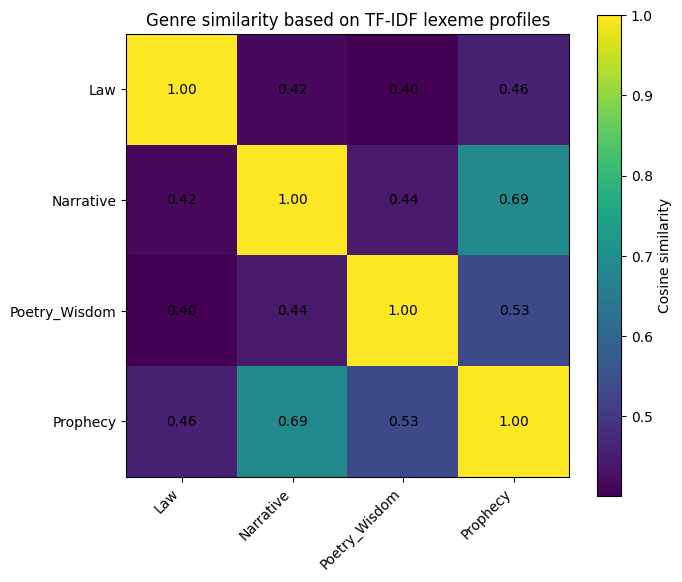

Saved: /content/drive/MyDrive/ALPcourse_Biblical_Hebrew_Project/biblical_hebrew_genre_analysis/output/figures/genre_cosine_similarity_heatmap.png


In [4]:
plt.figure(figsize=(7, 6))
plt.imshow(similarity_df.values)
plt.xticks(range(len(genres)), genres, rotation=45, ha="right")
plt.yticks(range(len(genres)), genres)
plt.colorbar(label="Cosine similarity")
plt.title("Genre similarity based on TF-IDF lexeme profiles")

for i in range(len(genres)):
    for j in range(len(genres)):
        plt.text(j, i, f"{similarity_df.iloc[i, j]:.2f}", ha="center", va="center")

plt.tight_layout()
filename = FIGURES_DIR / "genre_cosine_similarity_heatmap.png"
plt.savefig(filename, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", filename)

## 5. Book-level similarity

Genre labels are useful, but biblical books are the more natural textual units. This section checks whether books from similar genres are close to each other in vector space.

In [5]:
book_documents = (
    content.assign(book_genre=content["genre"] + " | " + content["book"])
    .groupby("book_genre")["lex_clean"]
    .apply(lambda values: " ".join(values.astype(str)))
    .sort_index()
)

book_vectorizer = TfidfVectorizer(lowercase=False, tokenizer=str.split, token_pattern=None)
XB = book_vectorizer.fit_transform(book_documents.values)

book_labels = list(book_documents.index)
book_similarity = pd.DataFrame(cosine_similarity(XB), index=book_labels, columns=book_labels)
book_similarity.to_csv(TABLES_DIR / "book_cosine_similarity.csv")

# Convert the similarity matrix into a ranked edge list.
edges = []
for i, source in enumerate(book_labels):
    for j, target in enumerate(book_labels):
        if i < j:
            edges.append({
                "source": source,
                "target": target,
                "cosine_similarity": book_similarity.iloc[i, j],
            })

book_edges = pd.DataFrame(edges).sort_values("cosine_similarity", ascending=False)
book_edges.to_csv(TABLES_DIR / "book_similarity_edges.csv", index=False)

book_edges.head(20)

,source,target,cosine_similarity
21,Narrative | Samuel_I,Prophecy | Jesaia,0.593444
13,Narrative | Genesis,Narrative | Samuel_I,0.588661
20,Narrative | Samuel_I,Prophecy | Amos,0.539921
27,Prophecy | Amos,Prophecy | Jesaia,0.522470
26,Poetry_Wisdom | Psalmi,Prophecy | Jesaia,0.473925
17,Narrative | Genesis,Prophecy | Jesaia,0.471400
2,Law | Deuteronomium,Narrative | Samuel_I,0.458091
16,Narrative | Genesis,Prophecy | Amos,0.455637
22,Poetry_Wisdom | Proverbia,Poetry_Wisdom | Psalmi,0.431093
6,Law | Deuteronomium,Prophecy | Jesaia,0.411019


## 6. Interpretation notes

In [6]:
interpretation = '''
Similarity analysis checks whether the genre groups differ not only by their most frequent or most distinctive words,
but also by their overall lexical profile. High similarity means that two genres/books share many weighted lexemes.
Low similarity suggests more distinctive vocabulary. These distances can later be converted into a network.
'''

print(interpretation)


Similarity analysis checks whether the genre groups differ not only by their most frequent or most distinctive words,
but also by their overall lexical profile. High similarity means that two genres/books share many weighted lexemes.
Low similarity suggests more distinctive vocabulary. These distances can later be converted into a network.

